<div align="center"></div>

**Misión:** Los superhéroes necesitan un sistema automático para identificar si alguien es héroe o villano usando sus atributos.

**Algoritmos cubiertos:**
1. Regresión Logística
2. Árbol de Decisión
3. Random Forest
4. SVM (Support Vector Machine)
5. K-NN (K-Nearest Neighbors)
6. Matriz de Confusión (evaluación final)

## 📦 Instalación de dependencias

In [1]:
# Si no lo tienes instalado, ejecuta esta celda para instalar las librerías necesarias
#!pip install scikit-learn pandas numpy matplotlib seaborn

## 📚 Importaciones

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### Explicación de cada paso:

1. **Dataset**: Creamos un dataset ficticio con características de héroes y villanos, asegurando que haya una mezcla de ambos.   
2. **Preprocesamiento**: Dividimos el dataset en entrenamiento y prueba, y estandarizamos las características para mejorar el rendimiento de los modelos.   
3. **Modelos**: Entrenaremos varios modelos de clasificación para comparar su desempeño en la tarea de distinguir héroes de villanos. 


## 🗂️ Dataset: La Base de Datos Secreta de la Liga de Héroes

| Característica | Rango | Descripción |
|---|---|---|
| `fuerza` | 0-100 | ¿Cuánto puede levantar? |
| `inteligencia` | 0-100 | ¿Sabe hacer los impuestos? |
| `carisma` | 0-100 | ¿Le siguen en redes? |
| `nivel_ego` | 0-100 | ¿Habla de sí mismo en tercera persona? |
| `mascotas_malas` | 0/1 | ¿Tiene tiburones con rayos láser? |
| `capa` | 0/1 | ¿Usa capa? (importante indicador) |

**Etiqueta:** `1 = Héroe` | `0 = Villano`

In [3]:
np.random.seed(42)
n = 200

heroes = {
    "nombre": [
        "Spider-Man","Wonder Woman","Iron Man","Black Panther","Capitana Marvel",
        "Thor","Hulk","Black Widow","Hawkeye","Ant-Man","Doctor Strange",
        "Scarlet Witch","Visión","Falcon","War Machine","Shazam","Aquaman",
        "Flash","Green Lantern","Cyborg","Supergirl","Batgirl","Zatanna",
        "Ms. Marvel","Moon Knight","She-Hulk","America Chavez","Ironheart",
        "Kate Bishop","Yelena Belova"
    ] + [f"Héroe_Anónimo_{i}" for i in range(n//2 - 30)],
    "fuerza":       np.concatenate([[75,90,70,85,95,98,100,60,55,50,65,85,80,65,75,88,92,70,68,78,94,62,60,70,72,88,85,80,58,62], np.random.randint(55, 100, n//2 - 30)]),
    "inteligencia": np.concatenate([[95,85,100,92,80,72,45,98,85,88,99,90,95,82,85,78,75,88,85,90,88,97,92,83,80,90,87,96,88,92], np.random.randint(60, 100, n//2 - 30)]),
    "carisma":      np.concatenate([[88,95,85,90,87,90,60,80,75,82,78,85,72,80,70,92,88,90,85,80,88,85,90,90,75,88,85,80,82,80], np.random.randint(60, 100, n//2 - 30)]),
    "nivel_ego":    np.concatenate([[40,30,75,25,35,60,20,15,10,20,45,30,10,15,20,35,40,30,25,20,25,15,20,20,30,30,20,30,15,15], np.random.randint(5, 50, n//2 - 30)]),
    "mascotas_malas": np.concatenate([[0]*30, np.random.choice([0,1], n//2 - 30, p=[0.9, 0.1])]),
    "capa":         np.concatenate([[0,1,0,1,0,1,0,0,0,0,1,1,1,0,0,1,0,0,0,0,0,1,1,0,1,0,0,0,0,0], np.random.choice([0,1], n//2 - 30, p=[0.5, 0.5])]),
    "etiqueta":     [1] * (n//2)
}

villanos = {
    "nombre": [
        "Thanos","Loki","Ultron","Red Skull","Magneto","Joker","Lex Luthor","Brainiac",
        "Reverse Flash","Sinestro","Doctora Doom","Hela","Dormammu","Kang","M.O.D.O.K.",
        "Zemo","Yellowjacket","Justin Hammer","Whiplash","Abominación",
        "Venom (malo)","Mysterio","Vulture","Electro","Rhino",
        "Scorpion","Sandman","Lizard","Shocker","Hydro-Man"
    ] + [f"Villano_Anónimo_{i}" for i in range(n//2 - 30)],
    "fuerza":       np.concatenate([[100,70,95,75,88,50,65,80,85,72,85,95,100,82,60,65,70,40,75,95,88,75,70,80,85,78,80,75,65,72], np.random.randint(40, 95, n//2 - 30)]),
    "inteligencia": np.concatenate([[90,95,98,85,95,88,100,100,92,85,99,80,85,98,72,88,80,75,70,45,60,90,78,65,50,60,55,80,65,55], np.random.randint(40, 95, n//2 - 30)]),
    "carisma":      np.concatenate([[70,90,60,50,75,95,85,55,65,60,70,80,50,75,40,80,55,70,60,40,55,75,70,60,50,55,50,55,50,45], np.random.randint(30, 80, n//2 - 30)]),
    "nivel_ego":    np.concatenate([[95,85,90,100,88,80,95,85,90,80,95,92,100,88,75,82,85,90,80,70,65,80,78,75,72,70,68,72,70,65], np.random.randint(60, 100, n//2 - 30)]),
    "mascotas_malas": np.concatenate([[1,0,1,1,0,0,1,1,0,0,1,1,1,1,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0], np.random.choice([0,1], n//2 - 30, p=[0.4, 0.6])]),
    "capa":         np.concatenate([[1,1,0,1,1,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0], np.random.choice([0,1], n//2 - 30, p=[0.6, 0.4])]),
    "etiqueta":     [0] * (n//2)
}

df_heroes   = pd.DataFrame(heroes)
df_villanos = pd.DataFrame(villanos)
df = pd.concat([df_heroes, df_villanos], ignore_index=True).sample(frac=1, random_state=42)

print(f"📋 Dataset: {len(df)} individuos registrados")
print(f"   Héroes:   {df['etiqueta'].sum()}")
print(f"   Villanos: {(df['etiqueta'] == 0).sum()}")
print("\n🔍 Muestra del dataset:")
df[["nombre","fuerza","inteligencia","carisma","nivel_ego","mascotas_malas","capa","etiqueta"]].head(8)

📋 Dataset: 200 individuos registrados
   Héroes:   100
   Villanos: 100

🔍 Muestra del dataset:


,nombre,fuerza,inteligencia,carisma,nivel_ego,mascotas_malas,capa,etiqueta
95,Héroe_Anónimo_65,80,63,75,37,0,0,1
15,Shazam,88,78,92,35,0,1,1
30,Héroe_Anónimo_0,93,73,74,33,0,1,1
158,Villano_Anónimo_28,65,44,57,77,1,0,0
128,Shocker,65,65,50,70,0,0,0
115,Zemo,65,88,80,82,0,0,0
69,Héroe_Anónimo_39,63,83,96,20,0,0,1
170,Villano_Anónimo_40,89,92,62,80,1,0,0


## ⚙️ Preparación de los datos

In [4]:
# Que vamos a hacer:
# 1. Preprocesar los datos (dividir en entrenamiento y prueba, estandarizar características)
# 2. Entrenar varios modelos de clasificación
# 3. Evaluar su desempeño y comparar resultados 


features = ["fuerza", "inteligencia", "carisma", "nivel_ego", "mascotas_malas", "capa"]
X = df[features].values
y = df["etiqueta"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y) # Dividimos el dataset en entrenamiento (75%) y prueba (25%), manteniendo la proporción de clases
scaler = StandardScaler() # Creamos un objeto para estandarizar las características
X_train_sc = scaler.fit_transform(X_train) # Estandarizamos las características para que tengan media 0 y desviación estándar 1
X_test_sc  = scaler.transform(X_test) # Aplicamos la misma transformación al conjunto de prueba
resultados = {} # Diccionario para almacenar los resultados de cada modelo
print(f"✅ Train: {len(X_train)} muestras | Test: {len(X_test)} muestras")



✅ Train: 150 muestras | Test: 50 muestras


# Modelos de clasificación

<div align="center"></div>

🧪 **MISIÓN**: Loki está llenando solicitudes para unirse a los
Vengadores con diferentes identidades. S.H.I.E.L.D. 

Necesitamos un clasificador rápido que dé una PROBABILIDAD de si el solicitante es héroe o un disfrazado de azul y verde.

**¿Cómo funciona?**
La Regresión Logística aplica una función sigmoide a una
combinación lineal de las características para producir una probabilidad entre 0 y 1.

$$P(héroe) = \frac{1}{1 + e^{-z}} \quad \text{donde} \quad z = w \cdot x + b$$

In [ ]:

print("\n" + "=" * 60)
print("⚡ EJERCICIO 1: REGRESIÓN LOGÍSTICA")
print("   'El detector de Lokis infiltrados'")
print("=" * 60)

# Importamos el modelo de regresión logística
from sklearn.linear_model import LogisticRegression 


modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train_sc, y_train) 
y_pred_lr = modelo_lr.predict(X_test_sc) 
acc_lr = accuracy_score(y_test, y_pred_lr) 
resultados["Regresión Logística"] = acc_lr 

print(f"✅ Precisión: {acc_lr:.2%}")
print("\n📊 Importancia de cada característica (coeficientes):")
for feat, coef in sorted(zip(features, modelo_lr.coef_[0]), key=lambda x: abs(x[1]), reverse=True):
    barra = "█" * int(abs(coef) * 10)
    signo = "🟢" if coef > 0 else "🔴"
    print(f"   {signo} {feat:<20} {coef:+.3f}  {barra}")





⚡ EJERCICIO 1: REGRESIÓN LOGÍSTICA
   'El detector de Lokis infiltrados'
✅ Precisión: 98.00%

📊 Importancia de cada característica (coeficientes):
   🔴 nivel_ego            -3.415  ██████████████████████████████████
   🟢 carisma              +1.098  ██████████
   🟢 capa                 +0.407  ████
   🟢 inteligencia         +0.332  ███
   🟢 fuerza               +0.257  ██
   🔴 mascotas_malas       -0.201  ██



### Explicación:

Es uno de los algoritmos de clasificación más utilizados en el mundo real, especialmente en medicina, finanzas y ciencias sociales.
Utiliza una fórmula matemática (una curva en forma de "S" llamada función sigmoide) para calcular la probabilidad de que algo pertenezca a una clase.

- (max_iter=1000) --> La Regresión Logística usa un motor matemático que busca la mejor solución paso a paso (iterando)
- (max_iter=1000) --> indica el numero de pasos para buscar la mejor solución. 
- (X_train_sc) --> escalaridad en los datos.
- modelo_lr.coef_[0] --> indica la importancia de la variable y en qué dirección empuja.
- Con el bucle for que obtenemos?:

        - La magnitud (El tamaño de la barra █): abs(coef) (el valor absoluto) para ordenar la lista de mayor a menor impacto.
        - La dirección (El signo 🟢 o 🔴).
  


**Vamos a predecir a loki, ¿heroe o villano?**

In [ ]:
# Simulamos un nuevo solicitante sospechoso (Loki disfrazado)


loki_disfrazado = np.array([[85, 95, 90, 85, 0, 1]]) 
loki_scaled = scaler.transform(loki_disfrazado) 
prob_heroe = modelo_lr.predict_proba(loki_scaled)[0][1] 
veredicto  = "HÉROE ✅" if prob_heroe > 0.5 else "VILLANO ⚠️  ¡Alerta Loki!" 


print(f"🕵️  Nuevo solicitante sospechoso...")
print(f"   Probabilidad de ser héroe: {prob_heroe:.1%}")
print(f"   Veredicto: {veredicto}")

print("\n📌 PARA REFLEXIONAR:")
print("   - Coeficiente positivo → empuja hacia 'héroe'")
print("   - Coeficiente negativo → empuja hacia 'villano'")




🕵️  Nuevo solicitante sospechoso...
   Probabilidad de ser héroe: 24.4%
   Veredicto: VILLANO ⚠️  ¡Alerta Loki!

📌 PARA REFLEXIONAR:
   - Coeficiente positivo → empuja hacia 'héroe'
   - Coeficiente negativo → empuja hacia 'villano'


<div align="center"></div>

🌳 **MISIÓN**: El Detective Batman necesita un sistema de reglas EXPLÍCITO que cualquier comisario Gordon pueda seguir sin un ordenador. 

"Si el ego es > 80 Y tiene mascota mala →
VILLANO". Árbol de Decisión al rescate.

**¿Cómo funciona?**
Divide el espacio de características usando preguntas
binarias (nodos), maximizando la pureza de cada hoja
(Gini o Entropía). El resultado es un árbol de reglas
legibles por humanos.

> 💡 **Tu turno:** prueba con distintos valores de `max_depth` (1-10)

In [ ]:
print("\n" + "=" * 60)
print("🌳 EJERCICIO 2: ÁRBOL DE DECISIÓN")
print("   'El manual de reglas del Detective Batman'")
print("=" * 60)

from sklearn.tree import DecisionTreeClassifier, export_text

# 👇 TU TURNO: prueba con distintos valores de max_depth (1-10)

modelo_dt = DecisionTreeClassifier(max_depth=4, random_state=42, criterion="gini") 
modelo_dt.fit(X_train, y_train) 
y_pred_dt = modelo_dt.predict(X_test) 

acc_dt = accuracy_score(y_test, y_pred_dt) 
resultados["Árbol de Decisión"] = acc_dt 

print(f"\n✅ Precisión: {acc_dt:.2%}") 
print(f"   Profundidad real del árbol: {modelo_dt.get_depth()}")
print(f"   Número de hojas: {modelo_dt.get_n_leaves()}") 

print("\n🌲 Reglas del árbol (manual del Detective Batman):") 
reglas = export_text(modelo_dt, feature_names=features) 

for i, linea in enumerate(reglas.split("\n")[:25]): 
    print("  ", linea)
if reglas.count("\n") > 25: 
    print("   ... (árbol completo disponible en 'reglas' variable)")

print("\n🏆 Importancia de características:")  
for feat, imp in sorted(zip(features, modelo_dt.feature_importances_), key=lambda x: x[1], reverse=True): 
    barra = "█" * int(imp * 40) # 
    print(f"   {feat:<20} {imp:.3f}  {'█' * int(imp * 40)}") 
    


print("\n📌 PARA REFLEXIONAR:")
print("   - ¿Qué pasa si aumentas max_depth=10? (sobreajuste)")
print("   - ¿Y con max_depth=1? (subajuste)")
print("   - ¿Puedes leer el árbol y entender la lógica?")


# que vemos en este ejercicio:
# - El árbol de decisión crea reglas basadas en las características para clasificar a los individuos
# - La profundidad del árbol controla la complejidad de las reglas (demasiado profundo = sobreajuste, demasiado superficial = subajuste)




🌳 EJERCICIO 2: ÁRBOL DE DECISIÓN
   'El manual de reglas del Detective Batman'

✅ Precisión: 96.00%
   Profundidad real del árbol: 1
   Número de hojas: 2

🌲 Reglas del árbol (manual del Detective Batman):
   |--- nivel_ego <= 53.00
   |   |--- class: 1
   |--- nivel_ego >  53.00
   |   |--- class: 0
   

🏆 Importancia de características:
   nivel_ego            1.000  ████████████████████████████████████████
   fuerza               0.000  
   inteligencia         0.000  
   carisma              0.000  
   mascotas_malas       0.000  
   capa                 0.000  

📌 PARA REFLEXIONAR:
   - ¿Qué pasa si aumentas max_depth=10? (sobreajuste)
   - ¿Y con max_depth=1? (subajuste)
   - ¿Puedes leer el árbol y entender la lógica?


### Explicación:

Este es probablemente el algoritmo más parecido a cómo pensamos los humanos. Básicamente, crea un diagrama de flujo de preguntas de "Sí o No" para llegar a una conclusión.

1. La Poda del Árbol:

    - (max_depth=4) --> Indica el numero de preguntas consecutivas que puedes hacer.
    - (criterion="gini") --> Es la fórmula matemática que usa el árbol para decidir qué pregunta hacer primero.
    - X_train (sin el _sc) --> no necesita escalar los datos. 

2. La Anatomía del Árbol:

    - (max_depth=4) --> Profundidad real: Esto te dice cuántos niveles de preguntas hizo realmente, 
      aunque hemos indicado 4, a veces el árbol encuentra la respuesta antes.
    - (leaves) --> Las "hojas" son los puntos finales del árbol donde se toma la decisión. 
      Si tiene 10 hojas, significa que hay 10 "perfiles" o caminos distintos que te llevan a una clasificación.

 3. El Manual del Detective:

    - (export_text) --> convierte la matemática del modelo en una serie de reglas condicionales (SI pasa esto... Y pasa esto otro...).

4. La Importancia de las Características: te muestra un ranking con barras (█), La característica con la barra más grande casi siempre corresponde a la "raíz" del árbol.
   El árbol solo te dice "cuánta impureza logró limpiar esta variable"



### Por si juguetas con el código:

**¿Por qué no cambia nada al subir max_depth=10?**
Porque el árbol ya convergió antes de llegar a profundidad 4. Recuerda este print:
pythonprint(f"   Profundidad real del árbol: {modelo_dt.get_depth()}")
Si te dice, por ejemplo, Profundidad real: 3, significa que el árbol encontró una solución óptima en profundidad 3 y no tiene nada más que dividir. Subir el límite a 10 no cambia nada porque el árbol se detiene solo antes.

**¿Cuándo SÍ cambiaría?**
Cambiaría si el árbol estuviera siendo podado por max_depth. Es decir, si la profundidad real fuera exactamente igual al max_depth que pusiste:
Profundidad realmax_depth¿Cambia al subir max_depth?34❌ No, ya convergió44✅ Sí, estaba limitado410❌ No, ya convergió

**¿Qué puedes hacer para forzar diferencias?**
Quita cualquier límite y ve hasta dónde llega solo
modelo_dt = DecisionTreeClassifier(max_depth=None, random_state=42)

**Luego compara profundidad real con max_depth=4**
print(modelo_dt.get_depth())
print(modelo_dt.get_n_leaves())
Con max_depth=None el árbol crece libremente. Si la precisión en test baja respecto a max_depth=4, habrás visto el sobreajuste en acción. Si no cambia, es que tus datos simplemente no tienen más complejidad que explotar.

<div align="center"></div>

🌲🌲🌲 **MISIÓN**: Un solo árbol puede ser engañado por Mystique
(la mutante que cambia de forma). Necesitamos un COMITÉ de
árboles que vote en conjunto. ¡El poder de la democraciamutante!

**¿Cómo funciona?**
Entrena N árboles de decisión, cada uno con una muestra
aleatoria del dataset (bagging) y características aleatorias.
La predicción final es la votación mayoritaria de todos.
→ Menos varianza, más robusto que un solo árbol.

> 💡 **Tu turno:** experimenta con `n_estimators` (10, 50, 100, 500)

In [ ]:
print("\n" + "=" * 60)
print("🌲🌲 EJERCICIO 3: RANDOM FOREST")
print("   'El comité anti-Mystique'")
print("=" * 60)

from sklearn.ensemble import RandomForestClassifier

# 👇 TU TURNO: experimenta con n_estimators (10, 50, 100, 500)

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_estimators = número de árboles en el bosque, 
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
resultados["Random Forest"] = acc_rf

print(f"\n✅ Precisión: {acc_rf:.2%}")
print(f"   Árboles en el bosque: {modelo_rf.n_estimators}")

print("\n🔮 Importancia de características (consenso del bosque):")
importancias = sorted(zip(features, modelo_rf.feature_importances_), key=lambda x: x[1], reverse=True)
for feat, imp in importancias:
    print(f"   {feat:<20} {imp:.3f}  {'█' * int(imp * 50)}")

#Que nos dice esto sobre nuestro comité anti-Mystique?
# - El Random Forest combina múltiples árboles de decisión para mejorar la precisión y reducir el sobreajuste
# - La importancia de características muestra cuáles son los factores más decisivos para clasificar a alguien como héroe o villano según el consenso de todos los árboles en el bosque





🌲🌲 EJERCICIO 3: RANDOM FOREST
   'El comité anti-Mystique'

✅ Precisión: 96.00%
   Árboles en el bosque: 100

🔮 Importancia de características (consenso del bosque):
   nivel_ego            0.679  █████████████████████████████████
   carisma              0.179  ████████
   inteligencia         0.074  ███
   mascotas_malas       0.039  █
   fuerza               0.025  █
   capa                 0.005  


### Explicación:

**Que nos dice esto sobre nuestro comité anti-Mystique?**

- El Random Forest combina múltiples árboles de decisión para mejorar la precisión y reducir el sobreajuste
- La importancia de características muestra cuáles son los factores más decisivos para clasificar a alguien como héroe o villano según el consenso de todos los árboles en el bosque


**Cómo funciona**:

Crea el modelo: RandomForestClassifier(...) prepara el bosque con 100 árboles.

    - fit(X_train, y_train) --> Entrena: hace que el modelo aprenda los patrones de los datos de entrenamiento.
    - predict(X_test) --> Predice: hace que el modelo intente adivinar los resultados de los datos de prueba.
    - accuracy_score(...) --> Evalúa: compara las predicciones del modelo con las respuestas reales (y_test) para sacar la nota final.

**Interpretación del ejercicio**:

- Precisioón 96%--> % de predicciones correctas que hizo el modelo
- n_estimators = número de árboles en el bosque, en este caso 100.
- Importancia de las características: es la parte mas analitica. Muestra las variables mas determinantes para la toma de decisiones.

##⚖️ **Simulación de votación del bosque para un caso concreto**

In [9]:

caso_dudoso = np.array([[72, 80, 75, 72, 1, 1]])  # ¿Magneto rehabilitado?
votos = np.array([tree.predict(caso_dudoso)[0] for tree in modelo_rf.estimators_])
votos_heroe   = votos.sum()
votos_villano = len(votos) - votos_heroe
print(f"\n⚖️  Caso 'Magneto pide asilo heroico':")
print(f"   Árboles que votan HÉROE:   {votos_heroe}")
print(f"   Árboles que votan VILLANO: {votos_villano}")
print(f"   Veredicto del bosque: {'HÉROE ✅' if votos_heroe > votos_villano else 'VILLANO ⚠️'}")

print("\n📌 PARA REFLEXIONAR:")
print("   - ¿Por qué Random Forest suele superar a un solo árbol?")
print("   - ¿Qué ventaja tiene la votación sobre una sola predicción?")


⚖️  Caso 'Magneto pide asilo heroico':
   Árboles que votan HÉROE:   3.0
   Árboles que votan VILLANO: 97.0
   Veredicto del bosque: VILLANO ⚠️

📌 PARA REFLEXIONAR:
   - ¿Por qué Random Forest suele superar a un solo árbol?
   - ¿Qué ventaja tiene la votación sobre una sola predicción?


<div align="center"></div>

🔮 **MISIÓN**: Professor X necesita un campo de fuerza mental
que separe PERFECTAMENTE a mutantes buenos y malos en el
espacio multidimensional. La SVM encontrará el hiperplano
que maximiza la distancia entre clases. ¡Como la Cámara
de Privacidad, pero matemática!

**¿Cómo funciona?**
Encuentra el hiperplano de mayor margen entre clases.
Con kernel RBF puede separar datos no lineales proyectándolos
a dimensiones superiores (¡dimensiones cuánticas!).
Parámetros clave: C (tolerancia errores) y gamma (influencia de cada punto).

> 💡 **Tu turno:** prueba `kernel='linear'`, `'poly'`, `'rbf'`, `'sigmoid'`

In [10]:
print("\n" + "=" * 60)
print("🔮 EJERCICIO 4: SVM (Support Vector Machine)")
print("   'El campo de fuerza mental del Profesor X'")
print("=" * 60)

from sklearn.svm import SVC

# 👇 TU TURNO: prueba kernel='linear', 'poly', 'rbf', 'sigmoid'

modelo_svm = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)
modelo_svm.fit(X_train_sc, y_train)
y_pred_svm = modelo_svm.predict(X_test_sc)

acc_svm = accuracy_score(y_test, y_pred_svm)
resultados["SVM"] = acc_svm

print(f"\n✅ Precisión: {acc_svm:.2%}")
print(f"   Kernel usado: {modelo_svm.kernel}")
print(f"   Vectores de soporte (los casos más difíciles de clasificar): {modelo_svm.n_support_}")
print(f"     → Héroes en el límite:   {modelo_svm.n_support_[1]}")
print(f"     → Villanos en el límite: {modelo_svm.n_support_[0]}")


🔮 EJERCICIO 4: SVM (Support Vector Machine)
   'El campo de fuerza mental del Profesor X'

✅ Precisión: 98.00%
   Kernel usado: rbf
   Vectores de soporte (los casos más difíciles de clasificar): [24 21]
     → Héroes en el límite:   21
     → Villanos en el límite: 24


### Explicación:

Este código hace exactamente lo mismo que el anterior (entrenar, predecir y evaluar), 
pero usando un algoritmo con una filosofía matemática completamente distinta, 
tiene varios parámetros importantes (hiperparámetros) que son:

    - (kernel="rbf") --> Esta es la "magia" del SVM. Un kernel define la forma en que el modelo dibuja la frontera para separar tus datos. 
    - (rbf )(Radial Basis Function) --> dibuja fronteras curvas y complejas.
    - (linear) ---> dibuja una línea recta, (poly) --> (dibuja curvas polinómicas) o (sigmoid)--> esto son los kernel, es importante elegir loskernel correctos.
    - (C=1.0) --> Es el nivel de "severidad" o penalización. Un valor bajo hace que el modelo sea tolerante a algunos errores para mantener una frontera suave. 
      Un valor alto obliga al modelo a intentar clasificar todo perfectamente.
    - (gamma="scale") --> Define qué tanta influencia tiene un solo punto de dato en la frontera de decisión. scale es un buen valor automático predeterminado.
    - (probability=True) --> Obliga al modelo a calcular probabilidades.

Para hacer la predicción:

    - Entrenamiento del modelo -->.fit(...) 
    - Genera respuestas para el examen --> .predict(...)
    - Calcula la precisión --> accuracy_score(...) 


🎭 **Caso extremo**: Deadpool (¿héroe? ¿villano? ¿mercenario carismático?)

In [11]:
deadpool = np.array([[80, 78, 99, 88, 0, 0]])  # ego alto pero sin mascota mala
prob_dp = modelo_svm.predict_proba(scaler.transform(deadpool))[0]

print(f"🎭 ¿Dónde queda Deadpool en el hiperplano?")
print(f"   Probabilidad héroe:   {prob_dp[1]:.1%}")
print(f"   Probabilidad villano: {prob_dp[0]:.1%}")
print(f"   La SVM dice: {'HÉROE ✅' if prob_dp[1] > 0.5 else 'VILLANO ⚠️'}")
print(f"   (Deadpool ha tuiteado que no está de acuerdo)")

print("\n📌 PARA REFLEXIONAR:")
print("   - kernel='linear' → frontera recta (simple)")
print("   - kernel='rbf'    → frontera curva (más flexible)")
print("   - Aumentar C → más ajustado al train (¿sobreajuste?)")
print("   - ¿Qué pasa con C=0.01 vs C=100?")


🎭 ¿Dónde queda Deadpool en el hiperplano?
   Probabilidad héroe:   6.1%
   Probabilidad villano: 93.9%
   La SVM dice: VILLANO ⚠️
   (Deadpool ha tuiteado que no está de acuerdo)

📌 PARA REFLEXIONAR:
   - kernel='linear' → frontera recta (simple)
   - kernel='rbf'    → frontera curva (más flexible)
   - Aumentar C → más ajustado al train (¿sobreajuste?)
   - ¿Qué pasa con C=0.01 vs C=100?


<div align="center"></div>

🗺️ **MISIÓN**: Groot solo dice "I am Groot", pero sus VECINOS
más cercanos (Rocket, Gamora, Star-Lord) pueden explicar
si alguien nuevo es Guardian de la Galaxia o agente de Thanos.
K-NN usa la sabiduría de los vecinos más similares.

**¿Cómo funciona?**
Para clasificar a un nuevo individuo, busca los K más
similares (distancia euclidiana u otra) y hace una votación.
No hay entrenamiento real → es un clasificador "perezoso".

> ⚠️ Necesita escalado: si fuerza va de 0-100 y capa de 0-1, la distancia estaría sesgada.

> 💡 **Tu turno:** experimenta con `k = 1, 3, 5, 11, 21, 51`

In [12]:
print("\n" + "=" * 60)
print("🗺️  EJERCICIO 5: K-NN (K-Nearest Neighbors)")
print("   'Dime quiénes son tus vecinos y te diré si eres Guardián'")
print("=" * 60)

from sklearn.neighbors import KNeighborsClassifier

# 👇 TU TURNO: experimenta con k = 1, 3, 5, 11, 21, 51

k = 5
modelo_knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
modelo_knn.fit(X_train_sc, y_train)
y_pred_knn = modelo_knn.predict(X_test_sc)

acc_knn = accuracy_score(y_test, y_pred_knn)
resultados["K-NN"] = acc_knn

print(f"✅ Precisión con K={k}: {acc_knn:.2%}")


🗺️  EJERCICIO 5: K-NN (K-Nearest Neighbors)
   'Dime quiénes son tus vecinos y te diré si eres Guardián'
✅ Precisión con K=5: 100.00%


### Explicación:

K-Vecinos Más Cercanos: "Dime con quién andas y te diré quién eres".
Es uno de los algoritmos más intuitivos que existen. Se llama un algoritmo de "aprendizaje perezoso".
¿Por qué? Porque en realidad no aprende ninguna fórmula matemática durante el entrenamiento (.fit). 
Lo único que hace es memorizar de memoria todos los datos de X_train_sc y predecir.

**Funcionamiento**:

    - (metric="euclidean")--> Saca su "regla" y mide la distancia en línea recta (distancia euclidiana) desde el nuevo dato hasta todos los demás datos que memorizó.
    - (n_neighbors=k) -->Se fija en los k (en este caso, 5) puntos que estén más cerca.
    - (Votación) --> Cuenta a qué clase pertenecen esos 5 vecinos. La clase que tenga la mayoría gana.

Utiliza Datos escalados **X_train_sc**--> el algoritmo se basa puramente en medir distancias, si una variable está en miles (ej. salario)
y otra en unidades (ej. edad), el salario dominará por completo el cálculo de la distancia y el modelo ignorará la edad. Al escalar, todas las variables pesan lo mismo.

**Interpretación de los resultados:**

    - K muy bajo (ej. k=1): El modelo es súper detallista y confía ciegamente en su vecino más cercano. Si ese vecino es una anomalía (un error en los datos), el modelo se equivocará. Se dice que el modelo "sobreajusta" (overfitting).
    - K muy alto (ej. k=51): El modelo hace encuestas masivas. Pierde los detalles locales y las fronteras se vuelven muy suaves. Si tu conjunto de datos tiene muchos más datos de la "Clase A" que de la "Clase B", un K muy alto hará que el modelo casi siempre prediga "Clase A" por pura superioridad numérica. Se dice que el modelo "subajusta" (underfitting).




🔬 Mini experimento: Buscar el K óptimo

In [13]:

print("\n🔬 Buscando el K óptimo (experimento rápido):")
ks = [1, 3, 5, 7, 9, 11, 15, 21]
accs_k = []
for ki in ks:
    m = KNeighborsClassifier(n_neighbors=ki)
    m.fit(X_train_sc, y_train)
    accs_k.append(accuracy_score(y_test, m.predict(X_test_sc)))

for ki, ac in zip(ks, accs_k):
    barra = "█" * int(ac * 40)
    marca = " ← óptimo" if ac == max(accs_k) else ""
    print(f"   K={ki:>2}  acc={ac:.2%}  {barra}{marca}")




🔬 Buscando el K óptimo (experimento rápido):
   K= 1  acc=98.00%  ███████████████████████████████████████
   K= 3  acc=100.00%  ████████████████████████████████████████ ← óptimo
   K= 5  acc=100.00%  ████████████████████████████████████████ ← óptimo
   K= 7  acc=98.00%  ███████████████████████████████████████
   K= 9  acc=100.00%  ████████████████████████████████████████ ← óptimo
   K=11  acc=98.00%  ███████████████████████████████████████
   K=15  acc=96.00%  ██████████████████████████████████████
   K=21  acc=100.00%  ████████████████████████████████████████ ← óptimo


🌿 **Groot presenta a un nuevo ser**

In [14]:
nuevo_ser = np.array([[68, 82, 78, 55, 0, 0]])
nuevo_sc  = scaler.transform(nuevo_ser)
vecinos_dist, vecinos_idx = modelo_knn.kneighbors(nuevo_sc)
etiquetas_vecinos = y_train[vecinos_idx[0]]

print(f"\n🌿 Groot trae a un desconocido para evaluación...")
print(f"   Sus {k} vecinos más cercanos votan:")
for i, (dist, etq) in enumerate(zip(vecinos_dist[0], etiquetas_vecinos)):
    rol = "Héroe ✅" if etq == 1 else "Villano ⚠️"
    print(f"     Vecino {i+1}: {rol}  (distancia: {dist:.2f})")
pred_nuevo = modelo_knn.predict(nuevo_sc)[0]

print(f"   → Veredicto final: {'HÉROE ✅' if pred_nuevo == 1 else 'VILLANO ⚠️'}")
print(f"   Groot: 'I am Groot.' (traducción: correcto)")

print("\n📌 PARA REFLEXIONAR:")
print("   - K=1 → memoriza exactamente el train (sobreajuste)")
print("   - K muy grande → ignora patrones locales (subajuste)")
print("   - ¿Por qué el escalado es OBLIGATORIO aquí?")


🌿 Groot trae a un desconocido para evaluación...
   Sus 5 vecinos más cercanos votan:
     Vecino 1: Héroe ✅  (distancia: 0.93)
     Vecino 2: Héroe ✅  (distancia: 1.09)
     Vecino 3: Héroe ✅  (distancia: 1.12)
     Vecino 4: Héroe ✅  (distancia: 1.14)
     Vecino 5: Villano ⚠️  (distancia: 1.15)
   → Veredicto final: HÉROE ✅
   Groot: 'I am Groot.' (traducción: correcto)

📌 PARA REFLEXIONAR:
   - K=1 → memoriza exactamente el train (sobreajuste)
   - K muy grande → ignora patrones locales (subajuste)
   - ¿Por qué el escalado es OBLIGATORIO aquí?


<div align="center"></div>

🎯 MISIÓN FINAL: Nick Fury necesita un informe completo. No solo "¿cuántos acertamos?", sino:

- ¿A cuántos villanos dejamos pasar haciéndose pasar por héroes?
  **Falsos Positivos** → ¡ERROR CRÍTICO!
      
- ¿A cuántos héroes acusamos injustamente de villanos?
  **Falsos Negativos** → también problemático

La Matriz de Confusión muestra los 4 escenarios posibles.

In [15]:
print("\n" + "=" * 60)
print("🎯 EJERCICIO 6: MATRIZ DE CONFUSIÓN")
print("   'El informe final de Nick Fury'")
print("=" * 60)

# Usamos Random Forest para el análisis (el mejor modelo)

cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()

print(f"""
  ┌─────────────────────────────────────────────────────┐
  │           MATRIZ DE CONFUSIÓN  (Random Forest)      │
  │              Pred: Héroe    Pred: Villano           │
  │  Real Héroe    TP={tp:<4} ✅       FN={fn:<4} ❌         │
  │  Real Villano  FP={fp:<4} ⚠️       TN={tn:<4} ✅         │
  └─────────────────────────────────────────────────────┘
  ✅ Verdaderos Positivos (TP={tp}): Héroes correctamente identificados
  ✅ Verdaderos Negativos (TN={tn}): Villanos correctamente detectados
  ❌ Falsos Positivos    (FP={fp}): Villanos que pasaron como héroes ← PELIGROSO
  ❌ Falsos Negativos    (FN={fn}): Héroes acusados injustamente ← INJUSTO
  """)

# Métricas derivadas

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
especific = tn / (tn + fp) if (tn + fp) > 0 else 0

print("📊 Métricas clave:")
print(f"   Accuracy    = (TP+TN)/Total = {(tp+tn)/(tp+tn+fp+fn):.2%}  ← % global de aciertos")
print(f"   Precision   = TP/(TP+FP)   = {precision:.2%}  ← de los que llamamos héroe, ¿cuántos lo son?")
print(f"   Recall      = TP/(TP+FN)   = {recall:.2%}  ← de todos los héroes, ¿cuántos encontramos?")
print(f"   F1-Score    = 2·P·R/(P+R)  = {f1:.2%}  ← balance precision-recall")
print(f"   Especific.  = TN/(TN+FP)   = {especific:.2%}  ← de todos los villanos, ¿cuántos detectamos?")

print("\n⚠️  DILEMA DE NICK FURY:")
print("   Si priorizas RECALL  → no te pierdes ningún héroe (pero acusas a inocentes)")
print("   Si priorizas PRECISION → no acusas inocentes (pero dejas escapar villanos)")
print("   F1-Score busca el equilibrio. ¿Cuál priorizarías tú?")




🎯 EJERCICIO 6: MATRIZ DE CONFUSIÓN
   'El informe final de Nick Fury'

  ┌─────────────────────────────────────────────────────┐
  │           MATRIZ DE CONFUSIÓN  (Random Forest)      │
  │              Pred: Héroe    Pred: Villano           │
  │  Real Héroe    TP=23   ✅       FN=2    ❌         │
  │  Real Villano  FP=0    ⚠️       TN=25   ✅         │
  └─────────────────────────────────────────────────────┘
  ✅ Verdaderos Positivos (TP=23): Héroes correctamente identificados
  ✅ Verdaderos Negativos (TN=25): Villanos correctamente detectados
  ❌ Falsos Positivos    (FP=0): Villanos que pasaron como héroes ← PELIGROSO
  ❌ Falsos Negativos    (FN=2): Héroes acusados injustamente ← INJUSTO
  
📊 Métricas clave:
   Accuracy    = (TP+TN)/Total = 96.00%  ← % global de aciertos
   Precision   = TP/(TP+FP)   = 100.00%  ← de los que llamamos héroe, ¿cuántos lo son?
   Recall      = TP/(TP+FN)   = 92.00%  ← de todos los héroes, ¿cuántos encontramos?
   F1-Score    = 2·P·R/(P+R)  = 95.83%  ← b

### Explicación:

**Desarmando la Matriz de Confusión **(cm.ravel())

La función confusion_matrix crea una tabla de 2x2. Al usar .ravel(), tu código "aplasta" esa tabla 
para sacar los cuatro números mágicos que definen todos los aciertos y errores de tu modelo.

** Las Métricas Clave**:

- **Precision** (Precisión Positiva): TP / (TP + FP). Mide la calidad de tus predicciones positivas.
    Si tienes muchos Falsos Positivos (villanos colándose), esta métrica caerá en picado.
- **Recall** (Exhaustividad o Sensibilidad): TP / (TP + FN). Mide la capacidad del modelo para "barrer" o encontrar todo lo que buscas.
    Si tienes muchos Falsos Negativos (héroes que no viste), esta métrica será muy baja.
- **F1-Score**: 2 · (Precision · Recall) / (Precision + Recall). Es la media armónica entre Precision y Recall. 
    Es la métrica definitiva si quieres un modelo equilibrado o si tienes datos muy desbalanceados. 
    Solo será alta si tanto la Precision como el Recall son buenos.
- **Especificidad** (Specificity): TN / (TN + FP). Es el equivalente al Recall, pero para la clase negativa.

### Visualización y gráficos


🎨 Generando visualización de la matriz de confusión...
   Guardado como 'shield_ml_report.png'


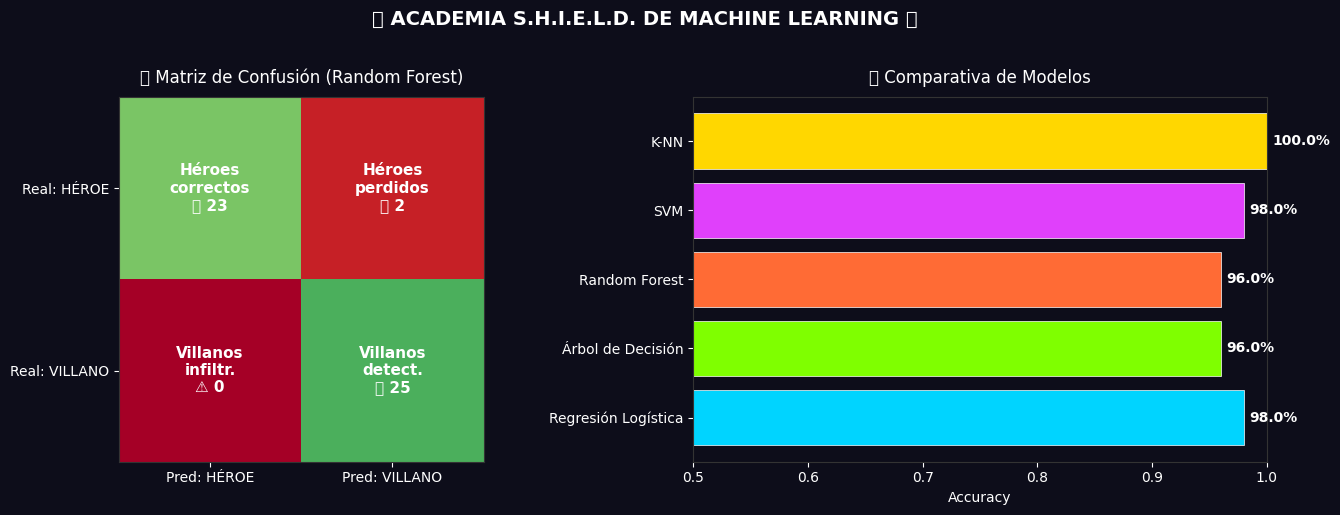

In [16]:
print("\n🎨 Generando visualización de la matriz de confusión...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0d0d1a")

# Gráfico 1: Matriz de confusión

ax = axes[0]
ax.set_facecolor("#0d0d1a")
labels = np.array([[f"Héroes\ncorrectos\n✅ {tp}", f"Héroes\nperdidos\n❌ {fn}"],
                   [f"Villanos\ninfiltr.\n⚠️ {fp}", f"Villanos\ndetect.\n✅ {tn}"]])
ax.imshow([[tp, fn], [fp, tn]], cmap="RdYlGn", vmin=0, vmax=max(tp, tn)+5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, labels[i,j], ha="center", va="center", fontsize=11, color="white", fontweight="bold")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Pred: HÉROE","Pred: VILLANO"], color="white")
ax.set_yticklabels(["Real: HÉROE","Real: VILLANO"], color="white")
ax.set_title("🎯 Matriz de Confusión (Random Forest)", color="white", pad=10)
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_edgecolor("#333")

# Gráfico 2: Comparativa de todos los modelos

ax2 = axes[1]
ax2.set_facecolor("#0d0d1a")
modelos = list(resultados.keys())
accs_all = list(resultados.values())
colores_bar = ["#00d4ff","#7fff00","#ff6b35","#e040fb","#ffd700"]
bars = ax2.barh(modelos, accs_all, color=colores_bar, edgecolor="white", linewidth=0.5)
ax2.set_xlim(0.5, 1.0)
ax2.set_xlabel("Accuracy", color="white")
ax2.set_title("🏆 Comparativa de Modelos", color="white", pad=10)
ax2.tick_params(colors="white")
for spine in ax2.spines.values(): spine.set_edgecolor("#333")
for bar, acc in zip(bars, accs_all):
    ax2.text(acc+0.005, bar.get_y()+bar.get_height()/2, f"{acc:.1%}", va="center", color="white", fontweight="bold")

plt.suptitle("🦸 ACADEMIA S.H.I.E.L.D. DE MACHINE LEARNING 🦹", color="white", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("shield_ml_report.png", dpi=150, bbox_inches="tight", facecolor="#0d0d1a")
print("   Guardado como 'shield_ml_report.png'")
plt.show()

<div align="center"></div>

In [17]:
print("\n" + "=" * 60)
print("🏆 INFORME FINAL DE NICK FURY")
print("=" * 60)
print("\nResultados de la operación de clasificación:\n")
ganador = max(resultados, key=resultados.get)
for modelo, acc in sorted(resultados.items(), key=lambda x: x[1], reverse=True):
    medalla = "🥇" if modelo == ganador else "  "
    print(f"  {medalla} {modelo:<22} {acc:.2%}  {'█' * int(acc * 30)}")

print(f"""
  🎖️  Ganador: {ganador} ({resultados[ganador]:.2%})

  Conclusión de Nick Fury:
  "Con estos modelos hemos protegido el mundo de infiltrados.
   Pero recuerden: ningún algoritmo es perfecto.
   Siempre habrá un Loki que se nos cuele..."

  📚 RETOS ADICIONALES:
  1. Añade más características: ¿tiene base secreta? ¿traicionó aliados?
  2. Prueba GridSearchCV para optimizar hiperparámetros
  3. Implementa validación cruzada (cross_val_score)
  4. ¿Qué pasa si el dataset está desbalanceado (90% héroes)?
  5. Añade un héroe real tuyo y clasifícalo con todos los modelos

  ¡La misión continúa, Agente! 🦸‍♀️
""")


🏆 INFORME FINAL DE NICK FURY

Resultados de la operación de clasificación:

  🥇 K-NN                   100.00%  ██████████████████████████████
     Regresión Logística    98.00%  █████████████████████████████
     SVM                    98.00%  █████████████████████████████
     Árbol de Decisión      96.00%  ████████████████████████████
     Random Forest          96.00%  ████████████████████████████

  🎖️  Ganador: K-NN (100.00%)

  Conclusión de Nick Fury:
  "Con estos modelos hemos protegido el mundo de infiltrados.
   Pero recuerden: ningún algoritmo es perfecto.
   Siempre habrá un Loki que se nos cuele..."

  📚 RETOS ADICIONALES:
  1. Añade más características: ¿tiene base secreta? ¿traicionó aliados?
  2. Prueba GridSearchCV para optimizar hiperparámetros
  3. Implementa validación cruzada (cross_val_score)
  4. ¿Qué pasa si el dataset está desbalanceado (90% héroes)?
  5. Añade un héroe real tuyo y clasifícalo con todos los modelos

  ¡La misión continúa, Agente! 🦸‍♀️

